<img src="logo_UNSAM.jpg" align="right" width="120" /> 
<br><br><br><br>
<div style="text-align: center;">

### Analisis y procesamiento de señales 1C 2026
# Trabajo Práctico Nº3

### Melanie amicucci

<br>
</div>

# Introducción
En este trabajo se estudió el fenómeno de desparramo espectral (spectral leakage) presente en el cálculo de la Transformada Discreta de Fourier (DFT). Este efecto aparece cuando la frecuencia de una señal senoidal no coincide exactamente con una de las frecuencias discretas analizadas por la DFT, produciendo una distribución de la energía espectral entre varios bins frecuenciales.

Para el analisis se generaron señales senoidales de potencia normalizada unitaria, utilizando distintos valores de frecuencia definidos a partir de:
$$
f_0 = k_0 \cdot \frac{f_s}{N} = k_0 \cdot \Delta f
$$
Donde 
 - fs es la frecuencia de muestreo
- N es la cantidad de muestras
- Δf es la resolución espectral de la DFT
- k0 es el bin de la frecuencia asociada a la señal

Se estudiaron tres casos de k0, con el objetivo de observar cómo pequeñas desintonías respecto de la grilla de bins producen cambios significativos en el espectro calculado.

## Definición de parámetros y generación de las señales
En primer lugar se definieron los parámetros principales de muestreo y análisis espectral. Se utilizó una frecuencia de muestreo:
$$
f_s = 1000 \text{ Hz}
$$
y una cantidad de muestras N=1000
A partir de estos valores se calculó la resolución espectral de la DFT:
$$
\Delta f = \frac{f_s}{N}
$$
la cual representa la separación en frecuencia entre bins consecutivos de la DFT. Para los valores utilizados:
$$
\Delta f = 1 \text{ Hz}
$$
Luego se definieron los tres casos de estudio correspondientes a distintos valores de (k_0):
$$
k_0 = \frac{N}{4}
$$
$$
k_1 = \frac{N}{4}+0.25
$$
$$
k_2 = \frac{N}{4}+0.5
$$
A partir de estos valores se calcularon las frecuencias de las señales senoidales mediante:
$$
f_0 = k_0 \cdot \Delta f
$$
obteniendose tres frecuencias desintonizadas respecto de la grilla de bins de la DFT.
Posteriormente se construyó el vector temporal:
$$
t[n] = \frac{n}{f_s}
$$
Finalmente, las señales senoidales se generaron mediante:
$$
x[n] = A \sin(2\pi f_0 t[n])
$$
utilizando una amplitud:
$$
A = \sqrt{2}
$$
de forma tal que la potencia promedio de cada señal resulte unitaria, ya que para una senoidal:
$$
P = \frac{A^2}{2}
$$
y por lo tanto:
$$
P = \frac{(\sqrt{2})^2}{2} = 1
$$


In [7]:
import numpy as np
import matplotlib.pyplot as plt

#%% PARAMETROS

fs = 1000          # frecuencia de muestreo CUANTAS MUESTRAS TOMA EL SISTEMA DE ADQ
N = 1000           # cantidad de muestras DE LA SEÑAL

# resolucion espectral: separacion entre los bins
deltaf = fs / N 

# caso1: k0 = N/4 BIN
k0 = N / 4
#caso2 
k1=  (N / 4) +0.25
#caso3
k2= ( N / 4) +0.5

# frecuencia de la senoidal para los 3 casos 
f0 = k0 * deltaf
f1= k1 * deltaf
f2= k2* deltaf
#%% VECTOR TEMPORAL, donde ocurre cada muestra, en que instante
#tiempo=N/fs porque la senoidal depende de t 

tt = np.arange(N) / fs #arange:generar una secuencia de numeros de maximo N-1 el ultimo xq toma el 0 primero
A = np.sqrt(2)     # potencia unitaria

Para los tres casos analizados se generaron las señales senoidales y posteriormente se calculó su Transformada Discreta de Fourier (DFT) utilizando la función FFT de NumPy. A partir de la FFT se obtuvo la densidad espectral de potencia (PSD) para estudiar cómo se distribuye la energía de cada señal en frecuencia.

Mediante la identidad de Parseval se verificó la conservación de la potencia entre el dominio temporal y el dominio frecuencial. Esta identidad establece que la potencia total de una señal debe ser la misma independientemente del dominio en el que se la analice.

En este caso, la potencia se calculó a partir de la suma de la densidad espectral de potencia:
$$
P = \frac{1}{N^2}\sum_{k=0}^{N-1}|X[k]|^2
$$
obteniéndose valores aproximadamente iguales a 1 para los tres casos analizados, verificando así que las señales poseen potencia unitaria.



In [8]:
#%%CASO 1 
xx0 = A * np.sin(2 * np.pi * f0 * tt)
# ecuacion de la fft
XX0 = np.fft.fft(xx0)
# DENSIDAD ESPECTRAL DE POTENCIA:
    #se ve ruido, leakage, aliasing
#como esta distribuida la potencia de la señal segun la frecuencia
#la potencia se reparte en muchas frecuencias: aparece un piso 

PSD0 = np.abs(XX0)**2 / N**2 #potencia espectral por definicion |x|^2
#/n^2 es para normalizarla, la pot cambia con la cantidad de muestras si no 


pot_nor1=np.sum(np.abs(XX0)**2)/N**2
print(pot_nor1)

#%% CASO 2 
xx1 = A * np.sin(2 * np.pi * f1 * tt)
# ecuacion de la fft
XX1 = np.fft.fft(xx1)
# DENSIDAD ESPECTRAL DE POTENCIA:
    #se ve ruido, leakage, aliasing
#como esta distribuida la potencia de la señal segun la frecuencia
#la potencia se reparte en muchas frecuencias: aparece un piso 

PSD1 = np.abs(XX1)**2 / N**2 #potencia espectral por definicion |x|^2
#/n^2 es para normalizarla, la pot cambia con la cantidad de muestras si no 

pot_nor2=np.sum(np.abs(XX1)**2)/N**2
print(pot_nor2)
#%% CASO 3
xx2 = A * np.sin(2 * np.pi * f2 * tt)
# ecuacion de la fft
XX2= np.fft.fft(xx2)
# DENSIDAD ESPECTRAL DE POTENCIA:
    #se ve ruido, leakage, aliasing
#como esta distribuida la potencia de la señal segun la frecuencia
#la potencia se reparte en muchas frecuencias: aparece un piso 

PSD2 = np.abs(XX2)**2 / N**2 #potencia espectral por definicion |x|^2
#/n^2 es para normalizarla, la pot cambia con la cantidad de muestras si no 

pot_nor3=np.sum(np.abs(XX2)**2)/N**2
print(pot_nor3)
#%%
# vector de frecuencias
ff = np.arange(N) * deltaf


1.0000000000000002
0.9989999999999996
1.0000000000000007


Esta impresión es la comprobación de la identidad de Parseval.

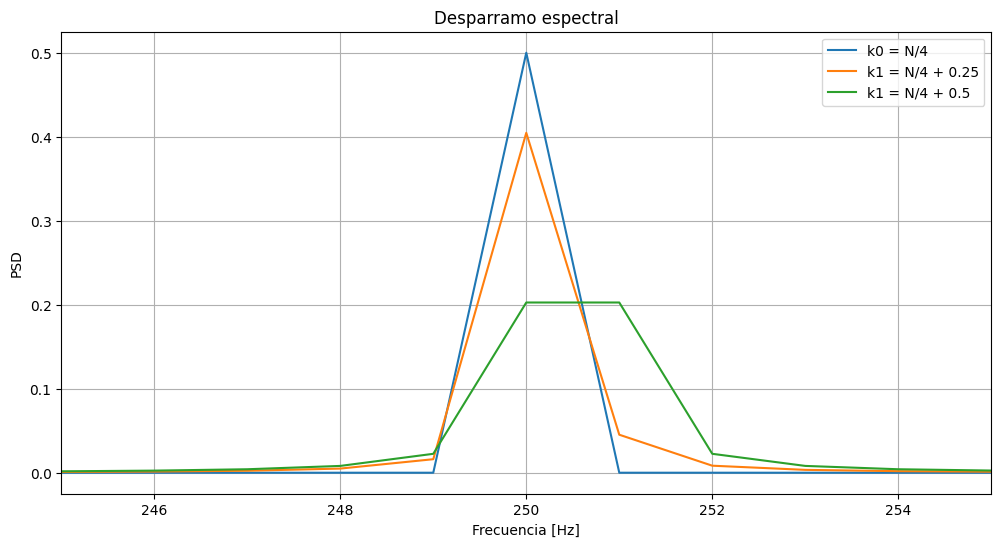

In [9]:
#%% GRAFICO

plt.figure(figsize=(12,6))

plt.plot(ff, PSD0, label='k0 = N/4')
plt.plot(ff, PSD1, label='k1 = N/4 + 0.25')
plt.plot(ff, PSD2, label='k1 = N/4 + 0.5')

plt.xlabel('Frecuencia [Hz]')

plt.ylabel('PSD')

plt.title('Desparramo espectral')
plt.xlim(245,255) #para poder ver las diferencias entre los 3 casos 

plt.grid()

plt.legend()

plt.show()

Figura 1: Densidades espectrales de potencia (PSD) para los tres casos analizados.

## ANALISIS DE RESULTADOS
A partir de los resultados obtenidos se observó el fenómeno de desparramo espectral asociado al cálculo de la DFT. En el primer caso, correspondiente a:
$$
k_0=\frac{N}{4}
$$
la frecuencia de la señal coincidió exactamente con uno de los bins de la DFT, por lo que la energía espectral permaneció concentrada en una única componente frecuencial. Esto produjo un espectro angosto y bien definido, prácticamente sin dispersión de energía hacia bins vecinos.
En cambio, para los casos:
$$
k_1=\frac{N}{4}+0.25
$$

$$
k_2=\frac{N}{4}+0.5
$$
la frecuencia de la señal quedó desintonizada respecto de la grilla discreta de frecuencias analizadas por la DFT. Como consecuencia, la energía comenzó a repartirse entre múltiples bins cercanos, mostrando un ensanchamiento del espectro y una disminución del pico principal.
Además, se verificó mediante la identidad de Parseval que la potencia total de las señales permaneció aproximadamente constante e igual a 1 en los tres casos. Esto demuestra que el desparramo espectral no implica perdida de energía, sino únicamente una redistribución de la misma entre distintas componentes frecuenciales.

Los resultados obtenidos permiten concluir que pequeñas variaciones en la frecuencia de una señal pueden generar cambios significativos en la representación espectral obtenida mediante la DFT, especialmente cuando la frecuencia no coincide exactamente con los bins de análisis.



## Aplicación de zero padding
Finalmente, se aplicó la técnica de zero padding con el objetivo de aumentar artificialmente la cantidad de puntos utilizados en el calculo de la FFT. Esta técnica consiste en agregar ceros al final de la señal original antes de calcular la transformada.
En este trabajo se agregaron ceros al final de cada señal, obteniendo una FFT de longitud total igual a:
$$
N_{pad}=10N
$$
De esta forma, la separación entre bins pasó a ser:
$$
\Delta f_{pad}=\frac{f_s}{N_{pad}}
$$
El objetivo del zero padding no es agregar nueva información a la señal, sino obtener una representación espectral más detallada y suave, permitiendo visualizar con mayor claridad la forma del desparramo espectral y la distribución de energía entre bins vecinos.


In [10]:
#%% PUNTO C - ZERO PADDING

# Nueva cantidad de puntos para la FFT
# La consigna pide agregar 9*N ceros al final:
# N original + 9*N ceros = 10*N puntos
Npad = 10 * N

# Agrego 9*N ceros al final de cada señal
xx0_pad = np.concatenate((xx0, np.zeros(9*N)))
xx1_pad = np.concatenate((xx1, np.zeros(9*N)))
xx2_pad = np.concatenate((xx2, np.zeros(9*N)))

# Calculo la FFT de las señales con zero padding
XX0_pad = np.fft.fft(xx0_pad)
XX1_pad = np.fft.fft(xx1_pad)
XX2_pad = np.fft.fft(xx2_pad)

# Nueva resolucion espectral ficticia
deltaf_pad = fs / Npad

# Nuevo vector de frecuencias
ff_pad = np.arange(Npad) * deltaf_pad

# Calculo la PSD con zero padding
# Se divide por N**2 porque la potencia real pertenece a la señal original de N muestras
PSD0_pad = np.abs(XX0_pad)**2 / N**2
PSD1_pad = np.abs(XX1_pad)**2 / N**2
PSD2_pad = np.abs(XX2_pad)**2 / N**2


Se graficaron las tres PSD con zero padding en un mismo gráfico, limitando la visualización al intervalo entre 245 Hz y 255 Hz para observar con mayor detalle la región donde se concentra la energía espectral.

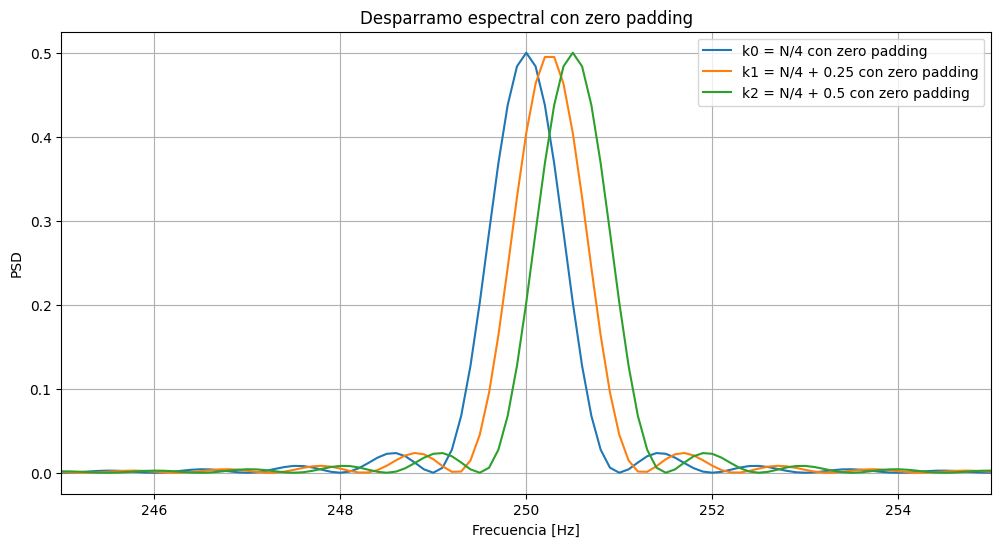

Delta f original: 1.0
Delta f con zero padding: 0.1


In [11]:
#%% GRAFICO CON ZERO PADDING

plt.figure(figsize=(12,6))

plt.plot(ff_pad, PSD0_pad, label='k0 = N/4 con zero padding')
plt.plot(ff_pad, PSD1_pad, label='k1 = N/4 + 0.25 con zero padding')
plt.plot(ff_pad, PSD2_pad, label='k2 = N/4 + 0.5 con zero padding')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD')
plt.title('Desparramo espectral con zero padding')

plt.xlim(245,255)

plt.grid()
plt.legend()
plt.show()

#%% COMPARACION DE RESOLUCIONES

print("Delta f original:", deltaf)
print("Delta f con zero padding:", deltaf_pad)

Figura2: densidades espectrales de potencia (psd)

## Análisis de resultados con zero padding

A partir de la aplicación de zero padding se obtuvo una representación espectral más detallada respecto del caso original. Al aumentar la cantidad de puntos utilizados en la FFT, la separación entre bins disminuyó, permitiendo observar con mayor claridad la forma de los lóbulos espectrales y la distribución de energía alrededor de la frecuencia principal.
En el caso:
$$
k_0=\frac{N}{4}
$$
la energía continuó concentrándose alrededor de una única componente principal, aunque ahora puede observarse una representación más suave y continua del espectro.

Para los casos desintonizados k1 y k2 el zero padding permitió visualizar con mayor detalle el desparramo espectral, mostrando el ensanchamiento del lobulo principal y la aparición de lobulos secundarios alrededor de la frecuencia central.

Ademas, se comprobó que el zero padding no elimina el fenomeno de leakage ni modifica la información real contenida en la señal. La energía total permanece constante y el desparramo sigue existiendo, simplemente se obtiene una representación espectral más detallada debido al aumento artificial de puntos en la FFT.


## Conclusión
Mediante el análisis de señales senoidales con frecuencias levemente desintonizadas respecto de los bins de la DFT, se observó que pequeñas variaciones en la frecuencia producen cambios significativos en la distribución espectral de la energía.

Los resultados mostraron que cuando la frecuencia de la señal coincide exactamente con un bin de la DFT, la energía permanece concentrada en una única componente espectral. En cambio, cuando la frecuencia queda desplazada respecto de la grilla frecuencial, la energía se distribuye entre múltiples bins vecinos, generando un desparramo espectral.

Además, mediante la identidad de Parseval se verificó que la potencia total de las señales se conserva en todos los casos, demostrando que el leakage no implica pérdida de energía sino una redistribución de la misma en el dominio frecuencial.

Finalmente, la aplicación de zero padding permitió obtener una representación espectral más detallada, facilitando la visualización de los lóbulos principales y secundarios del espectro. Sin embargo, se comprobó que esta técnica no elimina el desparramo espectral ni agrega nueva información a la señal, sino que únicamente mejora la resolución visual del espectro al aumentar artificialmente la cantidad de puntos de la FFT.

